# Arvores de Decisão

## Estudo 01 - Classificação de Risco de Crédito

### Objetivo

Este projeto foi desenvolvido com o objetivo de compreender os fundamentos da classificação supervisionada utilizando o algoritmo Arvore de Decisão

Durante o estudo, pude aplicar o algoritmo em um problema de risco de crédito, realizando previsões com base nas características dos clientes presentes na base de dados.

Mais do que obter uma previsão, o foco deste projeto foi entender como resolver um problema simples de aprovação de crédito
usando um fluxo básico de Machine Learning.


In [3]:
# Importando Bliblioteca
from sklearn.tree import DecisionTreeClassifier
import pickle

In [12]:
import pickle
with open(r'content\01.risco_credito\risco_credito.pkl', 'rb') as f:
    X_risco_credito, y_risco_credito = pickle.load(f)

In [14]:
#variaveis de entrada (ja aplicado com LabelEncoder)
X_risco_credito

,historia,divida,garantias,renda
0,2,0,1,0
1,1,0,1,1
2,1,1,1,1
3,1,1,1,2
4,1,1,1,2
5,1,1,0,2
6,2,1,1,0
7,2,1,0,2
8,0,1,1,2
9,0,0,0,2


In [16]:
#variaveis de previsao
y_risco_credito

0         alto
1         alto
2     moderado
3         alto
4        baixo
5        baixo
6         alto
7     moderado
8        baixo
9        baixo
10        alto
11    moderado
12       baixo
13        alto
Name: risco, dtype: str

In [29]:
#Treinando modelo no critério de divisao dos dados sendo o gini, mas pode ser entropy tambem
arvore_risco_credito = DecisionTreeClassifier(criterion='gini')
arvore_risco_credito.fit(X_risco_credito,y_risco_credito)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [30]:
#A importancia dos atributos de acordo com o atributo que possui o maior ganho de informação
arvore_risco_credito.feature_importances_

array([0.45833333, 0.08333333, 0.04166667, 0.41666667])

In [39]:
arvore_risco_credito.classes_

array(['alto', 'baixo', 'moderado'], dtype=object)

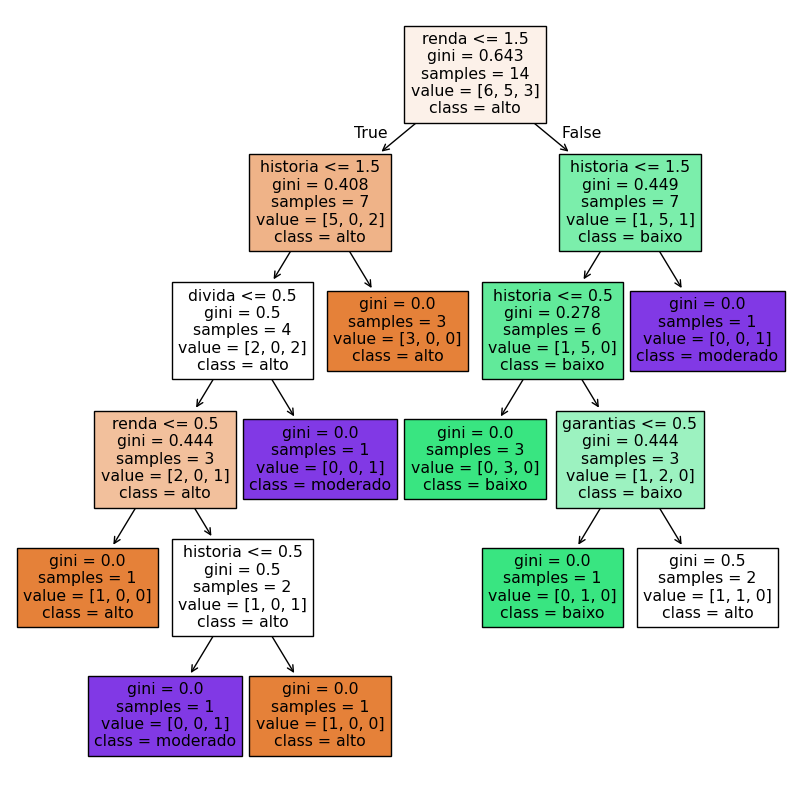

In [44]:
from sklearn import tree
import matplotlib.pyplot as plt

previsores = ['historia', 'divida', 'garantias', 'renda']

figura, eixos = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))

tree.plot_tree(
    arvore_risco_credito,
    feature_names=previsores,
    ax=eixos,
    class_names = arvore_risco_credito.classes_
    ,filled = True
);

plt.show()

**Realização de Previsoes**

In [46]:
#historia boa, divida alta, garantias nenhuma, renda > 35
#historia ruim, divida alta, garantias adequada, renda <15

previsoes = arvore_risco_credito.predict([[0,0,1,2],[2,0,0,0]])
previsoes

C:\Users\lucas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['baixo', 'alto'], dtype=object)

# Registro de Estudo – Árvores de Decisão

Neste estudo, apliquei Árvores de Decisão para classificação utilizando um conjunto de dados de risco de crédito. Consegui compreender o funcionamento básico do algoritmo, realizar o treinamento do modelo, visualizar a árvore gerada e resolver alguns problemas práticos encontrados durante a implementação.

Este notebook faz parte do meu processo contínuo de aprendizado e da construção do meu portfólio em Ciência de Dados.